# Goal in this assignment, is to correctly identify digits from a dataset of tens of thousands of handwritten images.



In [1]:
#!pip install statsmodels

In [2]:
# import right libraries
import numpy as np
import pandas as pd

# import ML libraries
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import MNLogit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
# import SV
from sklearn.svm import SVC
#Import gridsearchcv
from sklearn.model_selection import GridSearchCV
# Import K means
from sklearn.cluster import KMeans
# Import Adaboost
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier


# Import PCA
from sklearn.decomposition import PCA

# Using decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier


#from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_curve, auc
from sklearn import metrics

# import visualizations module
import matplotlib.pyplot as plt
import seaborn as sns

### Reading Training dataset

In [3]:
# Reading training set
df_digit_train = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
df_digit_test_main = pd.read_csv('/kaggle/input/digit-recognizer/test.csv')

### Understanding the data

In [4]:
# Print head of column
print("Head of data \n\n")
print(df_digit_train.head())

Head of data 


   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0   

In [5]:
# print shape of dataframe
print("Shape of data:",df_digit_train.shape)

Shape of data: (42000, 785)


In [6]:
# Print info of dataframe
print("Inforation about data \n\n")
print(df_digit_train.info())

Inforation about data 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB
None


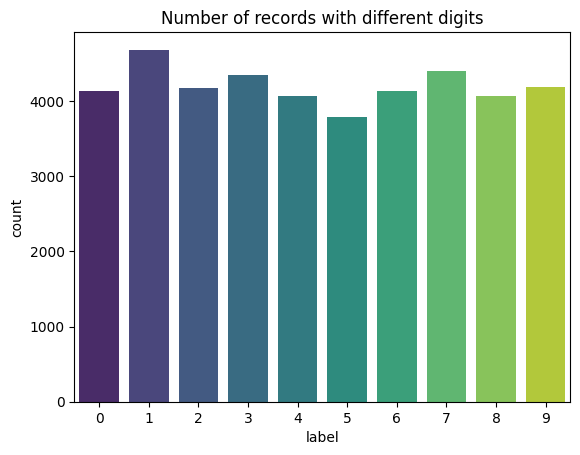

In [7]:
# plot the number of record with different digits
sns.countplot(x='label', data=df_digit_train, palette='viridis')
plt.title('Number of records with different digits')
plt.show()

In [8]:
def draw_digit(pixel,digit,n_range):

  plt.figure(figsize=(20,4))

  for index in range(n_range):  # Loop through the first 5 images
      image = pixel.iloc[index].values  # Get pixel values, excluding the label
      label = digit.iloc[index]  # Get the label
      # if label is series than just take first element
      if type(label) == pd.core.series.Series:
        label = label.iloc[0]
      plt.subplot(2, 10, index + 1)
      plt.imshow(np.reshape(image, (28,28)), cmap=plt.cm.Reds)
      plt.title(f"Label: {label}")
      plt.axis('on')
  plt.show()

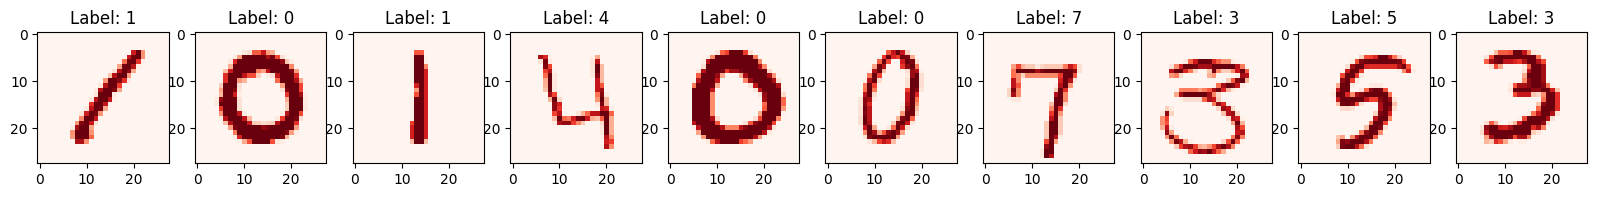

In [9]:
draw_digit(df_digit_train.iloc[:, 1:],df_digit_train.iloc[:, 0],10)

In [10]:
# Get the missing values of columns
print("Print Missing values of columns \n\n")
df_digit_train_null = pd.DataFrame(
    {
        'col_name': df_digit_train.isnull().sum().reset_index()['index'],
        'Null_Count': df_digit_train.isnull().sum().reset_index()[0]
    }
)
missing_val_count =0
for i in range(len(df_digit_train_null)):
  if df_digit_train_null['Null_Count'][i] != 0:
    missing_val_count = missing_val_count+1
    print(df_digit_train_null['col_name'][i],":",df_digit_train_null['Null_Count'][i])
if missing_val_count == 0:
  print("No missing values")

Print Missing values of columns 


No missing values


In [11]:
# Describe the data
print("Describe the data \n\n")
print(df_digit_train.describe())

Describe the data 


              label   pixel0   pixel1   pixel2   pixel3   pixel4   pixel5  \
count  42000.000000  42000.0  42000.0  42000.0  42000.0  42000.0  42000.0   
mean       4.456643      0.0      0.0      0.0      0.0      0.0      0.0   
std        2.887730      0.0      0.0      0.0      0.0      0.0      0.0   
min        0.000000      0.0      0.0      0.0      0.0      0.0      0.0   
25%        2.000000      0.0      0.0      0.0      0.0      0.0      0.0   
50%        4.000000      0.0      0.0      0.0      0.0      0.0      0.0   
75%        7.000000      0.0      0.0      0.0      0.0      0.0      0.0   
max        9.000000      0.0      0.0      0.0      0.0      0.0      0.0   

        pixel6   pixel7   pixel8  ...      pixel774      pixel775  \
count  42000.0  42000.0  42000.0  ...  42000.000000  42000.000000   
mean       0.0      0.0      0.0  ...      0.219286      0.117095   
std        0.0      0.0      0.0  ...      6.312890      4.633819   
min      

In [12]:
# Seperate the outcome classifier variable and independent variable
pixel_main = df_digit_train.iloc[:, 1:]  # Get pixel values, excluding the label
digit = df_digit_train.iloc[:, 0]  # Get the label
# print shape of X_digit and y_digit
print("Shape of X_digit:",pixel_main.shape,"\n\n")
print("Shape of y_digit:",digit.shape,"\n\n")
# print head
print("Head of pixel \n\n")
print(pixel_main.head())
print("Head of digit \n\n")
print(digit.head())

Shape of X_digit: (42000, 784) 


Shape of y_digit: (42000,) 


Head of pixel 


   pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0       0       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       0       0       0       0   
2       0       0       0       0       0       0       0       0       0   
3       0       0       0       0       0       0       0       0       0   
4       0       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0  

# Using standard scaler

In [13]:
# Using standard scaler
scaler = StandardScaler()
pixel = scaler.fit_transform(pixel_main)
pixel = pd.DataFrame(pixel,columns=pixel_main.columns)
df_digit_test = scaler.transform(df_digit_test_main)
# Convert df_digit_test to dataframe
df_digit_test = pd.DataFrame(df_digit_test,columns=df_digit_test_main.columns)

# If don't want to use standard scaler
#pixel = pixel_main
# copy the test data set-up
#df_digit_test = df_digit_test_main.copy()

## Use logistic regression model stats model

In [14]:
# Convert the target variable to categorical with one-hot encoding
#y_digit_onehot = pd.get_dummies(digit, prefix='digit',dtype = np.int16)

#y_digit_onehot
# Update the Logit model initialization
#digit_model = sm.MNLogit(y_digit_onehot, sm.add_constant(pixel))



In [15]:
# Fit the model and proceed with your analysis
#digit_model_fit = digit_model.fit()

#print(digit_model_fit.summary())

In [16]:
#y_pred = digit_model_fit.predict(sm.add_constant(X_digit_scaled))
#y_pred
# get distinct value of column y_pred
#unique_values = y_pred.iloc[:,0].unique()
#print("Print unique prediction", unique_values)

## Logistic regression multiclasifier using sklearn

In [17]:
# using sklearn for multi classifier with logistic regression model
clf = LogisticRegression(multi_class='multinomial', solver='lbfgs')
clf.fit(pixel, digit)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(multi_class='multinomial')

In [18]:
y_pred = clf.predict(pixel)
y_pred

array([1, 0, 1, ..., 7, 6, 9])

In [19]:
# Get confusion matrix
confusion_matrix(digit, y_pred)

array([[4064,    0,    9,    5,    4,   14,   16,    2,   15,    3],
       [   0, 4613,   10,   12,    1,    7,    3,    3,   27,    8],
       [   8,   20, 3917,   54,   26,   15,   22,   30,   70,   15],
       [   7,   10,   75, 4024,    2,  117,    5,   22,   58,   31],
       [   4,   15,   17,    3, 3892,    2,   22,    9,   14,   94],
       [  22,    6,   25,   95,   29, 3491,   35,    8,   68,   16],
       [  15,    3,   15,    2,   15,   36, 4037,    0,   13,    1],
       [   3,    8,   29,   10,   22,    2,    2, 4222,   10,   93],
       [  15,   47,   25,   84,    9,   75,   18,   12, 3740,   38],
       [   4,    8,    6,   39,   64,   22,    0,   88,   27, 3930]])

In [20]:
# get the accuracy score
accuracy_score(digit, y_pred)

0.9507142857142857

In [21]:
df_digit_test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.034737,-0.02527,-0.018026,-0.011473,-0.009099,-0.006897,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.034737,-0.02527,-0.018026,-0.011473,-0.009099,-0.006897,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.034737,-0.02527,-0.018026,-0.011473,-0.009099,-0.006897,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.034737,-0.02527,-0.018026,-0.011473,-0.009099,-0.006897,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.034737,-0.02527,-0.018026,-0.011473,-0.009099,-0.006897,0.0,0.0,0.0,0.0


In [22]:
# Predict test data
pixel_test = df_digit_test.iloc[:, 0:]  # Get pixel values, excluding the label
digit_test_pred = clf.predict(pixel_test)
digit_pred = pd.DataFrame(digit_test_pred,columns=['Label'])
digit_pred.head()


,Label
0,2
1,0
2,9
3,7
4,3


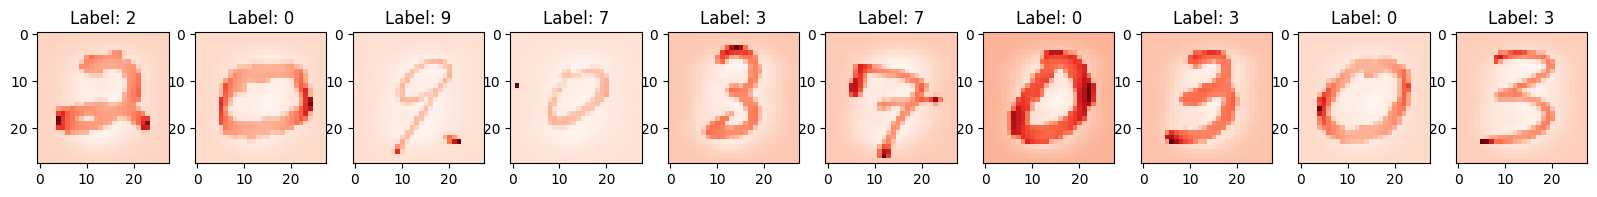

In [23]:

draw_digit(df_digit_test,digit_pred,10)


In [24]:
# Creating Model with Decision Tree
clf_tree = DecisionTreeClassifier()
clf_tree.fit(pixel, digit)

DecisionTreeClassifier()

In [25]:
# draw decision tree
print("Depth of tree", clf_tree.get_depth())
print("Number of leaves", clf_tree.get_n_leaves())
print("Number of features", clf_tree.n_features_in_)


Depth of tree 45
Number of leaves 3054
Number of features 784


In [26]:
# Predict test data
digit_test_pred_de = clf_tree.predict(pixel_test)
digit_pred_de = pd.DataFrame(digit_test_pred,columns=['Label'])
digit_pred_de.head()

,Label
0,2
1,0
2,9
3,7
4,3


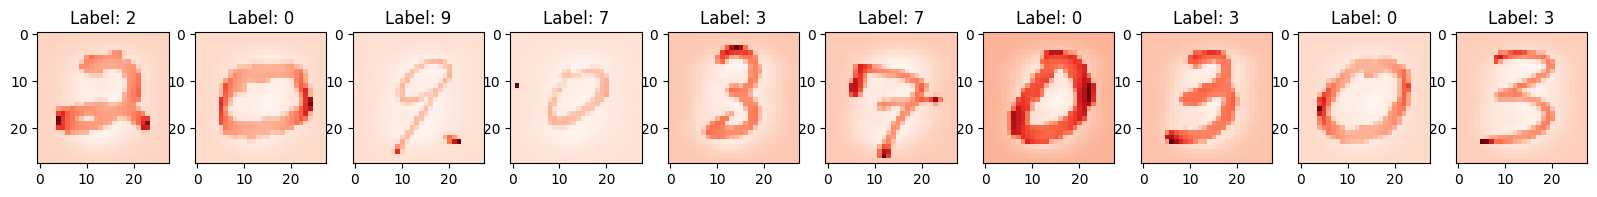

In [27]:
draw_digit(df_digit_test,digit_pred_de,10)

In [28]:
# Optimizing using grid search
clf_grid = DecisionTreeClassifier()
param_grid = {
    'max_depth': [10,15,20,22,24 ],
    'min_samples_split': [1,2,3,5]
}
grid_search = GridSearchCV(clf_grid, param_grid, cv=5,scoring='accuracy')
grid_search.fit(pixel, digit)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
25 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py", line 889, in fit
    super().fit(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py", line 177, in fit
    self._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 600, in _valida

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [10, 15, 20, 22, 24],
                         'min_samples_split': [1, 2, 3, 5]},
             scoring='accuracy')

In [29]:
clf_best = grid_search.best_estimator_
clf_best

DecisionTreeClassifier(max_depth=24)

In [30]:
# Print the best parameters
print("Best parameters:", grid_search.best_params_)

# Print the accuracy score of best predict
print("Best accuracy score:", grid_search.best_score_)

Best parameters: {'max_depth': 24, 'min_samples_split': 2}
Best accuracy score: 0.8585476190476189


In [31]:
# Predict test data

digit_test_pred_de_gcv = clf_best.predict(pixel_test)
digit_pred_de_gcv = pd.DataFrame(digit_test_pred,columns=['Label'])
digit_pred_de_gcv.head()

,Label
0,2
1,0
2,9
3,7
4,3


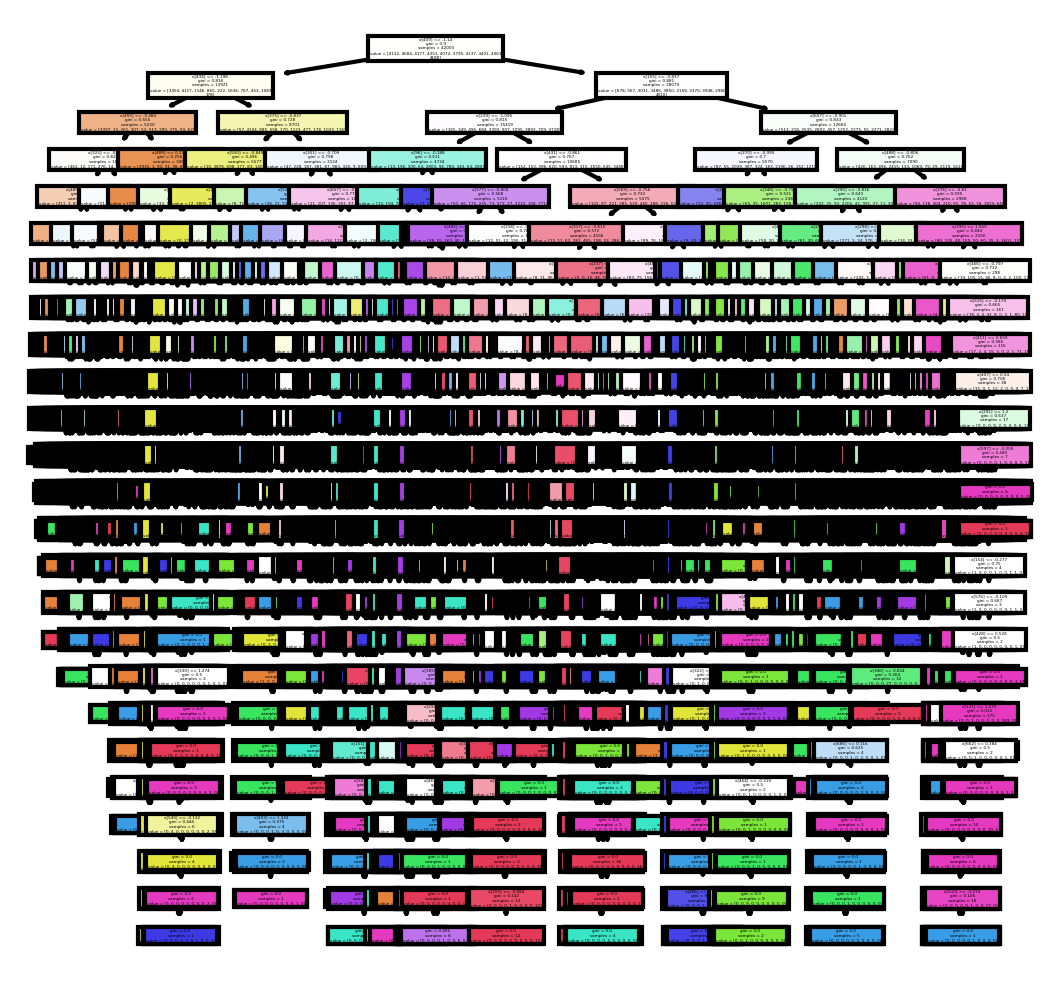

In [32]:
# Visualize decision score

fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (4,4), dpi = 300)
tree.plot_tree(clf_best, filled=True)
plt.show()


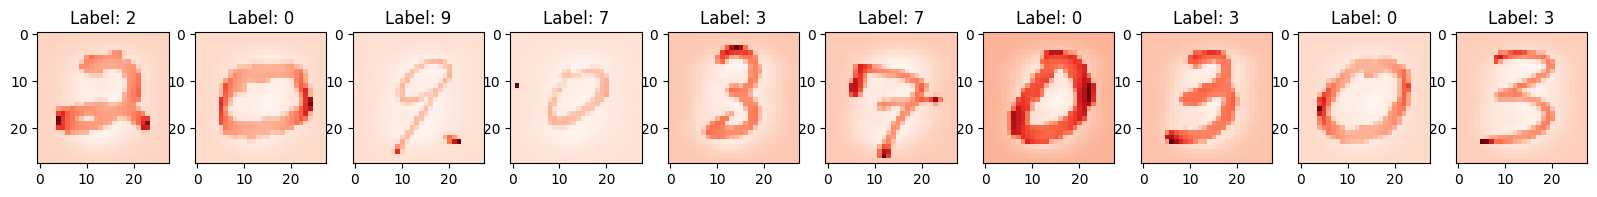

In [33]:
draw_digit(df_digit_test,digit_pred_de_gcv,10)

# Predicting using Random Forrest [Bagging]

In [34]:
#?RandomForestClassifier

In [35]:
RFC = RandomForestClassifier(n_estimators=300)
RFC.fit(pixel, digit)

RandomForestClassifier(n_estimators=300)

In [36]:
# Predict test data
digit_test_pred_RFC = RFC.predict(pixel_test)
digit_pred_RFC = pd.DataFrame(digit_test_pred,columns=['Label'])
digit_pred_RFC.head()


,Label
0,2
1,0
2,9
3,7
4,3


In [37]:
# put test prediction in dataframe
df_digit_pred_RFC = pd.DataFrame(digit_test_pred_RFC,columns=['Label'])
# include ImageId as index number
df_digit_pred_RFC['ImageId'] = df_digit_pred_RFC.index + 1
# reorder columns
df_digit_pred_RFC = df_digit_pred_RFC[['ImageId','Label']]
# Save the dataframe in excel
df_digit_pred_RFC.to_csv('/content/drive/MyDrive/Data-For-Analysis/Kaggle/Digit_Recognizer/digit_pred_RFC.csv', index=False)


OSError: Cannot save file into a non-existent directory: '/content/drive/MyDrive/Data-For-Analysis/Kaggle/Digit_Recognizer'

In [ ]:
draw_digit(df_digit_test,digit_pred_RFC,10)

In [ ]:
y_pred = RFC.predict(pixel)
print("accuracy score",accuracy_score(digit, y_pred))
#

# Bossting with Adavant

In [ ]:
digit_ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.2)
digit_ada.fit(pixel, digit)

In [ ]:
y_pred = digit_ada.predict(pixel)
print("accuracy score",accuracy_score(digit, y_pred))

In [ ]:
digit_test_pred_ada = digit_ada.predict(pixel_test)
digit_pred_ada = pd.DataFrame(digit_test_pred,columns=['Label'])
digit_pred_ada.head()

In [ ]:
draw_digit(df_digit_test,digit_pred_ada,10)

# Boosting using GBM method

In [ ]:
digit_gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.3)
digit_gbm.fit(pixel, digit)

In [ ]:
y_pred = digit_gbm.predict(pixel)
print("accuracy score",accuracy_score(digit, y_pred))

In [ ]:
digit_test_pred_gbm = digit_gbm.predict(pixel_test)
digit_pred_gbm = pd.DataFrame(digit_test_pred,columns=['Label'])
digit_pred_gbm.head()

In [ ]:
draw_digit(df_digit_test,digit_pred_gbm,10)

## Clusterring using K-Means

In [ ]:
# classify using K-Means unsupervised learning
k_means = KMeans(n_clusters=15,max_iter = 1000)
k_means.fit(pixel)

In [ ]:
digit_cluster_kmeans = k_means.predict(pixel)
df_digit_train_kmeans = df_digit_train.copy()
df_digit_train_kmeans['cluster'] = digit_cluster_kmeans
df_digit_train_kmeans.head()

In [ ]:
# Get count of different label based on cluster
cluster_grouping= df_digit_train_kmeans.groupby(['cluster','label']).size()
# change to dataframe
df_cluster_grouping = cluster_grouping.to_frame(name = 'count').reset_index()
df_cluster_grouping

In [ ]:
# plot the cluster label grouping
fig, axs = plt.subplots(5, 4, figsize=(15, 20))  # Create a 4x3 grid of subplots
#fig,ax = plt.subplot(121) #Alternative using subplot and 3 digit index

sns.barplot(x='label', y='count', hue='label', data=df_cluster_grouping[df_cluster_grouping.cluster == 0], ax=axs[0, 0])  # Plot on the first subplot (0, 0)
axs[0,0].set_title('Cluster 0')
sns.barplot(x='label', y='count', hue='label', data=df_cluster_grouping[df_cluster_grouping.cluster == 1], ax=axs[0, 1])  # Plot on the first subplot (0, 0)
axs[0,1].set_title('Cluster 1')
sns.barplot(x='label', y='count', hue='label', data=df_cluster_grouping[df_cluster_grouping.cluster == 2], ax=axs[0, 2])  # Plot on the first subplot (0, 0)
axs[0,2].set_title('Cluster 2')
sns.barplot(x='label', y='count', hue='label', data=df_cluster_grouping[df_cluster_grouping.cluster == 3], ax=axs[0, 3])  # Plot on the first subplot (0, 0)
axs[0,3].set_title('Cluster 3')

sns.barplot(x='label', y='count', hue='label', data=df_cluster_grouping[df_cluster_grouping.cluster == 4], ax=axs[1, 0])  # Plot on the first subplot (0, 0)
axs[1,0].set_title('Cluster 4')
sns.barplot(x='label', y='count', hue='label', data=df_cluster_grouping[df_cluster_grouping.cluster == 5], ax=axs[1, 1])  # Plot on the first subplot (0, 0)
axs[1,1].set_title('Cluster 5')
sns.barplot(x='label', y='count', hue='label', data=df_cluster_grouping[df_cluster_grouping.cluster == 6], ax=axs[1, 2])  # Plot on the first subplot (0, 0)
axs[1,2].set_title('Cluster 6')
sns.barplot(x='label', y='count', hue='label', data=df_cluster_grouping[df_cluster_grouping.cluster == 7], ax=axs[1, 3])  # Plot on the first subplot (0, 0)
axs[1,3].set_title('Cluster 7')

sns.barplot(x='label', y='count', hue='label', data=df_cluster_grouping[df_cluster_grouping.cluster == 8], ax=axs[2, 0])  # Plot on the first subplot (0, 0)
axs[2,0].set_title('Cluster 8')
sns.barplot(x='label', y='count', hue='label', data=df_cluster_grouping[df_cluster_grouping.cluster == 9], ax=axs[2, 1])  # Plot on the first subplot (0, 0)
axs[2,1].set_title('Cluster 9')
sns.barplot(x='label', y='count', hue='label', data=df_cluster_grouping[df_cluster_grouping.cluster == 10], ax=axs[2, 2])  # Plot on the first subplot (0, 0)
axs[2,2].set_title('Cluster 10')
sns.barplot(x='label', y='count', hue='label', data=df_cluster_grouping[df_cluster_grouping.cluster == 11], ax=axs[2, 3])  # Plot on the first subplot (0, 0)
axs[2,3].set_title('Cluster 11')

sns.barplot(x='label', y='count', hue='label', data=df_cluster_grouping[df_cluster_grouping.cluster == 12], ax=axs[3, 0])  # Plot on the first subplot (0, 0)
axs[3,0].set_title('Cluster 12')
sns.barplot(x='label', y='count', hue='label', data=df_cluster_grouping[df_cluster_grouping.cluster == 13], ax=axs[3, 1])  # Plot on the first subplot (0, 0)
axs[3,1].set_title('Cluster 13')
sns.barplot(x='label', y='count', hue='label', data=df_cluster_grouping[df_cluster_grouping.cluster == 14], ax=axs[3, 2])  # Plot on the first subplot (0, 0)
axs[3,2].set_title('Cluster 14')
sns.barplot(x='label', y='count', hue='label', data=df_cluster_grouping[df_cluster_grouping.cluster == 15], ax=axs[3, 3])  # Plot on the first subplot (0, 0)
axs[3,3].set_title('Cluster 15')

sns.barplot(x='label', y='count', hue='label', data=df_cluster_grouping[df_cluster_grouping.cluster == 16], ax=axs[4, 0])  # Plot on the first subplot (0, 0)
axs[4,0].set_title('Cluster 16')
sns.barplot(x='label', y='count', hue='label', data=df_cluster_grouping[df_cluster_grouping.cluster == 17], ax=axs[4, 1])  # Plot on the first subplot (0, 0)
axs[4,1].set_title('Cluster 17')
sns.barplot(x='label', y='count', hue='label', data=df_cluster_grouping[df_cluster_grouping.cluster == 18], ax=axs[4, 2])  # Plot on the first subplot (0, 0)
axs[4,2].set_title('Cluster 18')
sns.barplot(x='label', y='count', hue='label', data=df_cluster_grouping[df_cluster_grouping.cluster == 19], ax=axs[4, 3])  # Plot on the first subplot (0, 0)
axs[4,3].set_title('Cluster 19')


plt.tight_layout()  # Adjust subplot parameters for a tight layout
plt.show()


In [ ]:
# Using elbow curve
range_n_clusters = range(10, 120,10)
inertia =[]
silhouette_avg = []
for num_clusters in range_n_clusters:
  # Initialize and fit KMeans
  clusters = KMeans(n_clusters=num_clusters, max_iter=500)
  clusters.fit(pixel)
  # Get the inertia (sum of squared distances of samples to their closest cluster center)
  inertia.append(clusters.inertia_)

  #Compute the silhouette score
  silhouette_avg.append(metrics.silhouette_score(pixel, clusters.labels_))


In [ ]:
# draw elbow graph
plt.plot(range_n_clusters, inertia, 'bx--')
plt.xlabel('Values of K')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.show()

In [ ]:
# draw siloutte average
plt.plot(range_n_clusters, silhouette_avg, 'bx--')
plt.xlabel('Values of K')
plt.ylabel('Silhouette score')
plt.title('Silhouette analysis For Optimal k')
plt.show()


# Using Dendogram

In [ ]:
# Plot a dendogram on the pixel dataframe
from scipy.cluster.hierarchy import dendrogram, linkage
linkage = linkage(pixel, method='ward', metric='euclidean')
dendrogram(linkage)
plt.show()


## Using PCA analysis

In [ ]:
?PCA

In [ ]:
# implement PCA
pca = PCA(n_components=100)
pixel_pca = pca.fit_transform(pixel)
# Transform the test data
pixel_test_pca = pca.transform(pixel_test)
pixel_pca.shape

In [ ]:
# Using random forrest as it gave the best result
RFC_pca = RandomForestClassifier(n_estimators=300)
RFC_pca.fit(pixel_pca, digit)

In [ ]:
# check accuracy
y_pred = RFC_pca.predict(pixel_pca)
print("accuracy score",accuracy_score(digit, y_pred))

In [ ]:
# Predict test and draw digit
digit_test_pred_pca = RFC_pca.predict(pixel_test_pca)
digit_pred_pca = pd.DataFrame(digit_test_pred,columns=['Label'])
digit_pred_pca.head()

In [ ]:
# Draw font
draw_digit(df_digit_test,digit_pred_pca,10)

# Use Advant Method

In [ ]:
# Use Advant boosting method
digit_ada_pca = AdaBoostClassifier(n_estimators=400, learning_rate=0.3)
digit_ada_pca.fit(pixel_pca, digit)


In [ ]:
# get accuracy scor
y_pred = digit_ada_pca.predict(pixel_pca)
print("accuracy score",accuracy_score(digit, y_pred))

In [ ]:
# Predict the test
digit_test_pred_ada_pca = digit_ada_pca.predict(pixel_test_pca)
digit_pred_ada_pca = pd.DataFrame(digit_test_pred,columns=['Label'])
digit_pred_ada_pca.head()

In [ ]:
#draw the digit
draw_digit(df_digit_test,digit_pred_ada_pca,10)

# USing support vector machine

In [ ]:
# Predict using support vector machine
svc = SVC(kernel='linear')
svc.fit(pixel, digit)

In [ ]:
svc_pred = svc.predict(pixel)
print("accuracy score",accuracy_score(digit, svc_pred))

In [ ]:
#Predict Test digit
svc_pred_test = svc.predict(pixel_test)
svc_pred_test = pd.DataFrame(svc_pred_test,columns=['Label'])
svc_pred_test.head()

In [ ]:
# Draw the font
draw_digit(df_digit_test,svc_pred_test,10)

# Using SVM with Kernal poly

In [ ]:
# SVM with Kernal as poly
svc_poly = SVC(kernel='poly', degree=2)
svc_poly.fit(pixel, digit)

In [ ]:
# Get accuracy score
svc_poly_pred = svc_poly.predict(pixel)
print("accuracy score",accuracy_score(digit, svc_poly_pred))

In [ ]:
# Predict test
svc_poly_pred_test = svc_poly.predict(pixel_test)
svc_poly_pred_test = pd.DataFrame(svc_poly_pred_test,columns=['Label'])
svc_poly_pred_test.head()

In [ ]:
# Draw font
draw_digit(df_digit_test,svc_poly_pred_test,10)

In [ ]:
# SVC with kernal logistic
svc_log = SVC(kernel='sigmoid')
svc_log.fit(pixel, digit)

In [ ]:
#Get accuracy score
svc_log_pred = svc_log.predict(pixel)
print("accuracy score",accuracy_score(digit, svc_log_pred))
#Get argmax of support vector machine


In [ ]:
# Predict test
svc_log_pred_test = svc_log.predict(pixel_test)
svc_log_pred_test = pd.DataFrame(svc_log_pred_test,columns=['Label'])
svc_log_pred_test.head()

In [ ]:
#Draw Font
draw_digit(df_digit_test,svc_log_pred_test,10)

In [ ]:
# using rbf kernal
svc_rbf = SVC(kernel='rbf')
svc_rbf.fit(pixel, digit)

In [ ]:
# Getting accuracy score
svc_rbf_pred = svc_rbf.predict(pixel)
print("accuracy score",accuracy_score(digit, svc_rbf_pred))

In [ ]:
# Predicting test
svc_rbf_pred_test = svc_rbf.predict(pixel_test)
svc_rbf_pred_test = pd.DataFrame(svc_rbf_pred_test,columns=['Label'])
svc_rbf_pred_test.head()


In [ ]:
#drawing font
draw_digit(df_digit_test,svc_rbf_pred_test,10)